In [110]:
# imports
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction import DictVectorizer

In [111]:
df_train = pd.read_parquet('data/yellow_tripdata_2021-01.parquet')
df_val = pd.read_parquet('data/yellow_tripdata_2021-02.parquet')
# df_val = pd.read_parquet('data/yellow_tripdata_2021-03.parquet')
# df_val = pd.read_parquet('data/yellow_tripdata_2021-04.parquet')

In [112]:
df_train = df_train.iloc[:50000]
df_val = df_val.iloc[:50000]
df_train.shape, df_val.shape

((50000, 19), (50000, 19))

In [113]:
numeric_var = ['trip_distance']
categorical_var = ['trip_pu_do']

In [114]:
target_var = 'duration'

In [115]:
def preprocess(df, numeric_var, categorical_var):
    '''function to preprocess dataframe to return cleaned df'''
    
    df.columns = df.columns.str.lower().str.replace(' ', '_')
    df.pulocationid = df.pulocationid.astype(str) 
    df.dolocationid = df.dolocationid.astype(str)
    df['trip_pu_do'] = df['pulocationid'] + '_' + df['dolocationid']

    df['duration'] = df.tpep_dropoff_datetime - df.tpep_pickup_datetime
    df.duration = df.duration.apply(lambda x: float(x.total_seconds()/60))
    # df[(df.duration >= 0) & (df.duration <= 100)]
    df_filtered = df[(df.duration >= 1) & (df.duration <= 60)]
    print(f'feature cleaning done, shape: {df_filtered.shape}')

    return df_filtered

In [116]:
dv = DictVectorizer()

In [117]:
def dummy(df, numeric_var, categorical_var, dv, transform=True):
    '''function to preprocess dataframe to return vectorized dict'''
    
    dummies = pd.get_dummies(df[categorical_var], prefix='trip_', drop_first=True)
    print('dummy variables done')
    
    dicts = df[categorical_var + numeric_var].to_dict(orient='records')
    print(f'Status of transform: {transform}')
    if transform==True:
        print('performing X = dv.fit_transform(dicts)')
        X = dv.fit_transform(dicts)
    elif transform==False:
        print('performing X = dv.fit(dicts)')
        X = dv.transform(dicts)
    else:
        print('transform unsuccessful')
    print(f'preprocessing done, shape: {X.shape}')
    
    return X

    

In [118]:
df_train_pre = preprocess(df_train, numeric_var, categorical_var)
df_val_pre = preprocess(df_val, numeric_var, categorical_var)

feature cleaning done, shape: (49117, 21)
feature cleaning done, shape: (49205, 21)


In [119]:
y_train = df_train_pre[target_var]
y_val = df_val_pre[target_var]
print(y_train.shape)
print(y_val.shape)

(49117,)
(49205,)


In [120]:
print(df_train_pre.duration.describe())
print(' ')
print(df_val_pre.duration.describe())

count    49117.000000
mean        11.174242
std          8.278356
min          1.000000
25%          5.316667
50%          8.816667
75%         14.433333
max         59.800000
Name: duration, dtype: float64
 
count    49205.000000
mean        11.432862
std          8.078517
min          1.000000
25%          5.800000
50%          9.266667
75%         14.683333
max         59.866667
Name: duration, dtype: float64


In [121]:
X_train = dummy(df_train_pre, numeric_var, categorical_var, dv, transform=True)

dummy variables done
Status of transform: True
performing X = dv.fit_transform(dicts)
preprocessing done, shape: (49117, 6015)


In [122]:
X_val = dummy(df_val_pre, numeric_var, categorical_var, dv, transform=False)

dummy variables done
Status of transform: False
performing X = dv.fit(dicts)
preprocessing done, shape: (49205, 6015)


In [123]:
print(type(X_train))
print(type(X_val))

<class 'scipy.sparse._csr.csr_matrix'>
<class 'scipy.sparse._csr.csr_matrix'>


In [124]:
# # new step one hot encoding
# # 1. Create the OneHotEncoder

# from sklearn.preprocessing import OneHotEncoder
# from sklearn.linear_model import LinearRegression
# from sklearn.compose import ColumnTransformer
# from sklearn.pipeline import Pipeline

# # handle_unknown='ignore' is key!
# # drop='first' avoids multicollinearity
# encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False, drop='first')

# # 2. Create a ColumnTransformer
# # This applies the encoder to categorical columns and does nothing (passthrough) to numeric ones
# preprocessor = ColumnTransformer(
#     transformers=[
#         ('num', 'passthrough', numeric_var),
#         ('cat', encoder, categorical_var)
#     ],
#     remainder='passthrough' # Pass through any columns not specified (safer)
# )
# # --- Create the Full Pipeline (Preprocessing + Model) ---
# model = Pipeline(steps=[
#     ('preprocessor', preprocessor),
#     ('regressor', LinearRegression())
# ])
# # --- Train the Model ---
# # The preprocessor is fit ONLY on X_train within the pipeline's fit method
# model.fit(X_train, y_train)

# # --- Make Predictions on Validation Data ---
# # The preprocessor uses the fitted encoder to transform X_val
# y_pred_val = model.predict(X_val)

# # --- Evaluate ---
# mse = mean_squared_error(y_val, y_pred_val)
# print(f"Validation MSE: {mse}")


# # --- Inspect the transformed data (optional) ---
# # Get the fitted preprocessor step
# fitted_preprocessor = model.named_steps['preprocessor']

# # Transform train and validation sets explicitly to see the columns
# X_train_transformed = pd.DataFrame(
#     fitted_preprocessor.transform(X_train),
#     columns=fitted_preprocessor.get_feature_names_out()
# )
# X_val_transformed = pd.DataFrame(
#     fitted_preprocessor.transform(X_val),
#     columns=fitted_preprocessor.get_feature_names_out()
# )

# print("\nTransformed Training Data Head:\n", X_train_transformed.head())
# print("\nTransformed Validation Data Head:\n", X_val_transformed.head())
# print("\nColumns are consistent:", list(X_train_transformed.columns) == list(X_val_transformed.columns))

# # Note how 'Color_Yellow' column doesn't exist because it wasn't in training.
# # Rows in X_val_transformed where Color was 'Yellow' will have 0s for 'cat__Color_Green' and 'cat__Color_Red'.
# # Note how 'Size_S' column exists in both, even if not all sizes were in both original sets.



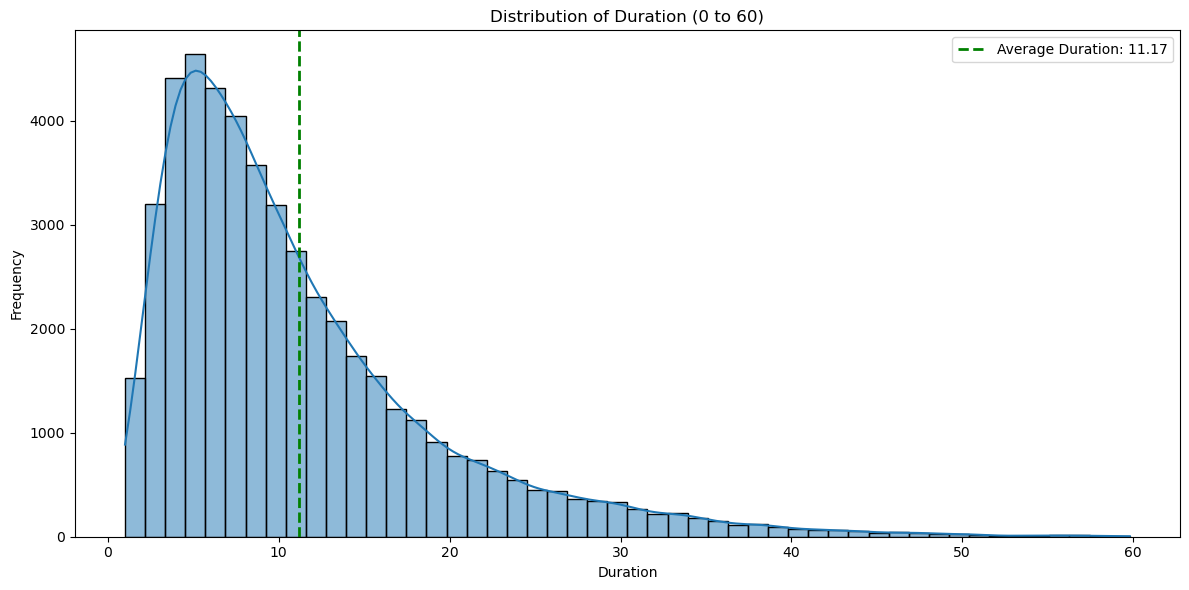

In [156]:

import seaborn as sns


# 1. Filter the DataFrame
filtered_df = df_train_pre

# 2. Calculate the average of the filtered duration
average_duration = filtered_df['duration'].mean()

# 3. Set up the plot figure and axes
plt.figure(figsize=(12, 6)) # Control figure size

# 4. Create the histogram using Seaborn
ax = sns.histplot(data=filtered_df, x='duration', bins=50, kde=True) # Using fewer bins for better visualization, added KDE curve

# 5. Add the vertical line for the average
ax.axvline(average_duration, color='green', linestyle='--', linewidth=2,
            label=f'Average Duration: {average_duration:.2f}') # Add label for legend

# 6. Add titles and labels for clarity
ax.set_title('Distribution of Duration (0 to 60)')
ax.set_xlabel('Duration')
ax.set_ylabel('Frequency')

# 7. Add a legend to explain the vertical line
ax.legend()

# Set figure background color to black (optional, for the area outside the plot
# 8. Ensure layout is tight and display the plot
plt.tight_layout()
plt.show()

In [126]:
print(y_train[:5])
print(y_val[:5])

0     6.033333
2    27.600000
3    15.216667
4    16.533333
5     8.016667
Name: duration, dtype: float64
0     7.683333
1    12.783333
2    24.616667
3    13.100000
4     3.716667
Name: duration, dtype: float64


/var/folders/2p/knkmky2x69s7jl6b1s6y8s3r0000gn/T/ipykernel_58367/1993671502.py:1: FutureWarning: The behavior of `series[i:j]` with an integer-dtype index is deprecated. In a future version, this will be treated as *label-based* indexing, consistent with e.g. `series[i]` lookups. To retain the old behavior, use `series.iloc[i:j]`. To get the future behavior, use `series.loc[i:j]`.
  print(y_train[:5])
/var/folders/2p/knkmky2x69s7jl6b1s6y8s3r0000gn/T/ipykernel_58367/1993671502.py:2: FutureWarning: The behavior of `series[i:j]` with an integer-dtype index is deprecated. In a future version, this will be treated as *label-based* indexing, consistent with e.g. `series[i]` lookups. To retain the old behavior, use `series.iloc[i:j]`. To get the future behavior, use `series.loc[i:j]`.
  print(y_val[:5])


In [127]:
from sklearn.linear_model import LinearRegression

param_grid = {'copy_X': [True, False], 
              'fit_intercept': [True, False], 
              'n_jobs': [None],
              'positive': [True, False]}

In [128]:
lr = LinearRegression()
lr.fit(X_train, y_train)

LinearRegression()

In [129]:
y_pred_train = lr.predict(X_train)
print(y_pred_train[:5])
print(y_train[:5])

[ 9.00785203 28.88077078 14.34326917 14.60393569 11.3246954 ]
0     6.033333
2    27.600000
3    15.216667
4    16.533333
5     8.016667
Name: duration, dtype: float64


/var/folders/2p/knkmky2x69s7jl6b1s6y8s3r0000gn/T/ipykernel_58367/2954526830.py:3: FutureWarning: The behavior of `series[i:j]` with an integer-dtype index is deprecated. In a future version, this will be treated as *label-based* indexing, consistent with e.g. `series[i]` lookups. To retain the old behavior, use `series.iloc[i:j]`. To get the future behavior, use `series.loc[i:j]`.
  print(y_train[:5])


In [130]:
y_pred_val = lr.predict(X_val)
print(y_pred_val[:5])
print(y_val[:5])

[ 7.07555811  7.75927639 16.84925868 11.27477539  3.27731285]
0     7.683333
1    12.783333
2    24.616667
3    13.100000
4     3.716667
Name: duration, dtype: float64


/var/folders/2p/knkmky2x69s7jl6b1s6y8s3r0000gn/T/ipykernel_58367/4146827939.py:3: FutureWarning: The behavior of `series[i:j]` with an integer-dtype index is deprecated. In a future version, this will be treated as *label-based* indexing, consistent with e.g. `series[i]` lookups. To retain the old behavior, use `series.iloc[i:j]`. To get the future behavior, use `series.loc[i:j]`.
  print(y_val[:5])


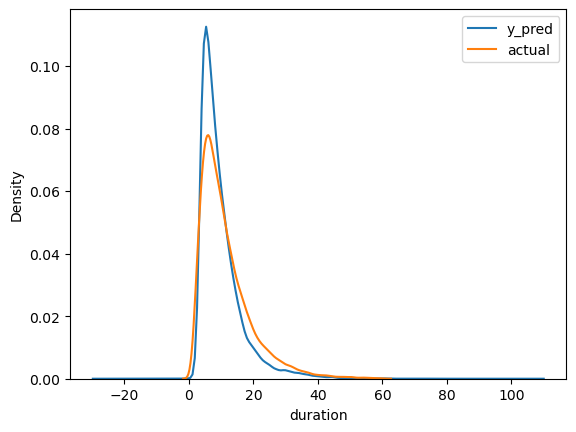

In [131]:
sns.kdeplot(y_pred_val, label='y_pred') 
# sns.kdeplot(y_pred_train, label='y_train')  
sns.kdeplot(y_val, label='actual') 
plt.legend()

In [132]:
from sklearn.metrics import mean_squared_error

In [133]:
print('error of train: ', mean_squared_error(y_pred_train, y_train, squared=False))
print('error of val: ', mean_squared_error(y_pred_val, y_val, squared=False))

error of train:  3.1143942156965188
error of val:  5.172074457815625


- error of train Jan 21:  3.3305286275463954  
- error of val Feb 21:  5.4703516573367805  
- error of val Mar 21:  5.0767966317387145  
- error of val Apr 21:  5.8599435344657715

In [146]:
y_train.mean()

11.174242455090225

In [135]:
lr.get_params()#.keys()


{'copy_X': True, 'fit_intercept': True, 'n_jobs': None, 'positive': False}

In [136]:

param_grid = {'copy_X': [True, False], 
              'fit_intercept': [True, False], 
              'n_jobs': [None],
              'positive': [True, False]}

# param_grid = {'copy_X': [True], 
#               'fit_intercept': [True], 
#               'n_jobs': [None],
#               'positive': [False]}

In [137]:
from sklearn.model_selection import GridSearchCV

In [138]:
lr2 = LinearRegression()

In [139]:
X_train.shape

(49117, 6015)

In [140]:
# # Instantiate gridsearch and define the metric to optimize 
# gs = GridSearchCV(lr2, param_grid, scoring='neg_mean_absolute_error',
#                   cv=2, verbose=3)

# # Fit gridsearch object to data.

# gs.fit(X_train.toarray(), y_train)



TEST

In [141]:
# #import all the classifiers you want to evaluate

# from sklearn.ensemble import GradientBoostingRegressor
# from sklearn.linear_model import ElasticNet
# from sklearn.svm import SVR
# from sklearn.linear_model import BayesianRidge
# # from catboost import CatBoostRegressor
# from sklearn.kernel_ridge import KernelRidge
# from sklearn.linear_model import LinearRegression
# # from xgboost.sklearn import XGBRegressor
# # from lightgbm import LGBMRegressor

# RSEED = 42

In [142]:
# models = []
# models.append(('GBR', GradientBoostingRegressor()))
# models.append(('EN', ElasticNet()))
# # models.append(('SVR', SVR()))
# models.append(('BR', BayesianRidge()))
# # models.append(('', CatBoostRegressor()))
# models.append(('KR', KernelRidge()))
# models.append(('LR', LinearRegression()))
# # models.append(('', XGBRegressor()))
# # models.append(('', KernelLGBMRegressorRidge())

In [143]:
# from sklearn.preprocessing import StandardScaler
# from sklearn.model_selection import train_test_split, cross_val_score
# from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
# from sklearn.model_selection import StratifiedKFold
# from sklearn.metrics import confusion_matrix, accuracy_score, classification_report, get_scorer_names

In [144]:
# # evaluate each model in turn
# results = []
# names = []
# for name, model in models:
#     model.fit(X_train, y_train)
#     y_pred = model.predict(X_train)
#     mse = mean_squared_error(y_train, y_pred, squared=False)
#     print(f'{name}: {mse:.4f}')